In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

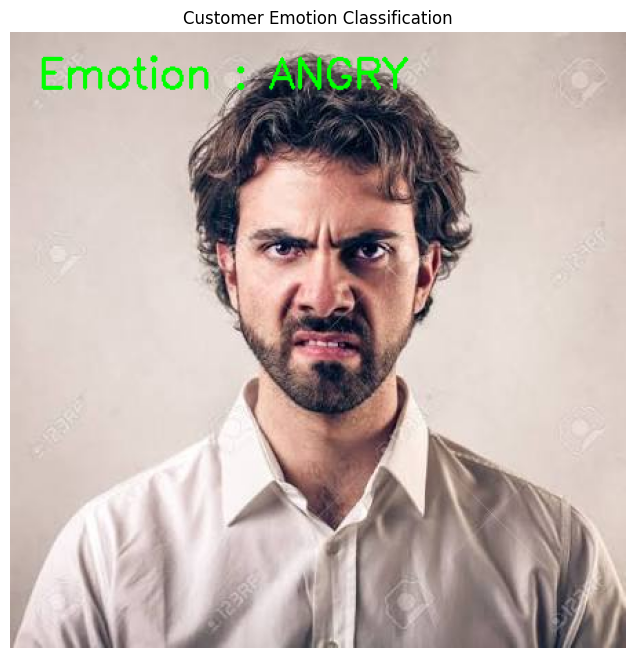

CUSTOMER EMOTION CLASSIFICATION REPORT
Angry        :  100.00%
Disgust      :    0.00%
Fear         :    0.00%
Happy        :    0.00%
Sad          :    0.00%
Surprise     :    0.00%
Neutral      :    0.00%

Dominant Emotion : Angry


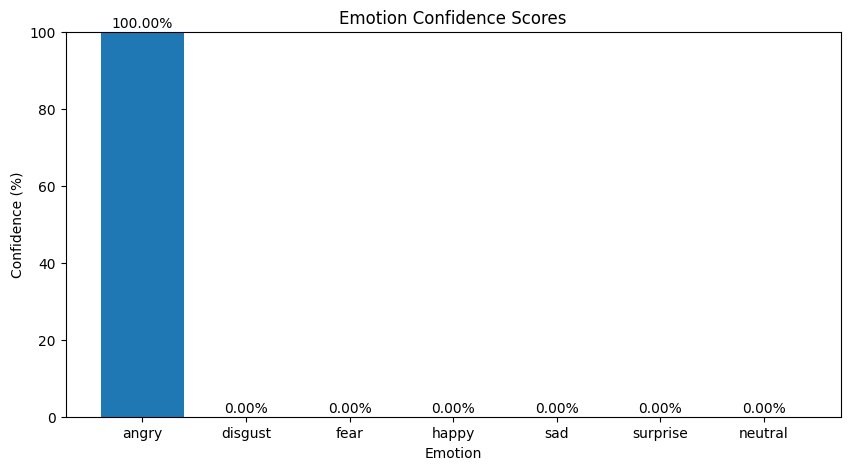


FINAL RESULT
Image Path          : /kaggle/input/datasets/sujalsangle/final-model-training/images.jpg
Detected Emotion    : Angry
Highest Confidence  : 100.0 %
Emotion Detection Completed Successfully.


In [12]:
# ============================================================
# Retail Store Customer Emotion Analysis using DeepFace
# Pre-trained Neural Network Model
# ============================================================

# Install required packages
!pip -q install deepface tf-keras

import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

# ============================================================
# CHANGE THIS PATH TO YOUR IMAGE
# ============================================================

image_path = "/kaggle/input/datasets/sujalsangle/final-model-training/images.jpg"

# Example:
# image_path = "/kaggle/input/customer/customer.jpg"

# ============================================================
# Analyze Emotion
# ============================================================

result = DeepFace.analyze(
    img_path=image_path,
    actions=["emotion"],
    enforce_detection=False
)

dominant_emotion = result[0]["dominant_emotion"]
emotion_scores = result[0]["emotion"]

# ============================================================
# Read Image
# ============================================================

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw Prediction
cv2.putText(
    img,
    f"Emotion : {dominant_emotion.upper()}",
    (20,40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0,255,0),
    2
)

# ============================================================
# Display Image
# ============================================================

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Customer Emotion Classification")
plt.axis("off")
plt.show()

# ============================================================
# Print Report
# ============================================================

print("="*50)
print("CUSTOMER EMOTION CLASSIFICATION REPORT")
print("="*50)

for emotion, confidence in emotion_scores.items():
    print(f"{emotion.capitalize():12} : {float(confidence):7.2f}%")

print("\nDominant Emotion :", dominant_emotion.capitalize())

# ============================================================
# Plot Confidence Scores
# ============================================================

labels = list(emotion_scores.keys())
values = [float(v) for v in emotion_scores.values()]

plt.figure(figsize=(10,5))
bars = plt.bar(labels, values)

plt.title("Emotion Confidence Scores")
plt.xlabel("Emotion")
plt.ylabel("Confidence (%)")
plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+1,
        f"{height:.2f}%",
        ha='center'
    )

plt.show()

# ============================================================
# Final Summary
# ============================================================

print("\n" + "="*50)
print("FINAL RESULT")
print("="*50)
print("Image Path          :", image_path)
print("Detected Emotion    :", dominant_emotion.capitalize())
print("Highest Confidence  :", round(max(values),2), "%")
print("="*50)
print("Emotion Detection Completed Successfully.")